# LECTURE 24
**Topic:** Convolution in the z-Domain; Frequency-Selective Filters  
**Textbook References:** Sections 4.5, 4.6.5

---

## Key Points

- **z-transform:** $X(z)=\sum_{n=-\infty}^{\infty}x[n]z^{-n}$
- Convolution in time = multiplication in z-domain: $y=h*x \Leftrightarrow Y(z)=H(z)X(z)$
- Ideal filters: piecewise constant amplitude response — unachievable in practice with FIR.
- FIR lowpass approximation: passband/stopband ripple $\delta$, transition band $[\Omega_p,\Omega_s]$.
- Symmetric coefficients ($b_n=b_{M-n}$) give linear phase: $\angle H(e^{j\Omega})=-M\Omega/2$.
- Larger $M$ = better approximation but longer delay ($M/2$ samples).


---
## Theory and Examples

### 1–4. z-Transform and Convolution

The z-transform is a power series:
$$X(z)=\sum_{n=-\infty}^{\infty}x[n]z^{-n}$$

For a finite-duration sequence (FIR filter): always converges (polynomial in $z^{-1}$).

**Key theorem:** $y=h*x \Leftrightarrow Y(z)=H(z)X(z)$

**Proof:** Direct multiplication of power series: coefficient of $z^{-n}$ in $H(z)X(z)$ is $\sum_k h[k]x[n-k]=(h*x)[n]$.

**Cascade:** $h^{(1)}*h^{(2)} \Leftrightarrow H_1(z)H_2(z)$

### 5. Example: z-transform multiplication

$[2,-1,1,-2]^T * [1,2,3,-1]^T = [2,3,5,-5,0,-7,2]^T$

Via polynomials: $(2-z^{-1}+z^{-2}-2z^{-3})(1+2z^{-1}+3z^{-2}-z^{-3}) = 2+3z^{-1}+5z^{-2}-5z^{-3}+0z^{-4}-7z^{-5}+2z^{-6}$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# z-transform polynomial multiplication
b_z=np.array([2,-1,1,-2])
x_z=np.array([1,2,3,-1])

# Linear convolution = polynomial multiplication
y_conv=np.convolve(b_z,x_z)
print('z-transform multiplication: (2-z^-1+z^-2-2z^-3)(1+2z^-1+3z^-2-z^-3)')
print(f'= {list(y_conv)}')
print('Expected: [2,3,5,-5,0,-7,2]')

# Polynomial format
print('\nPolynomial coefficients:')
for n,coef in enumerate(y_conv):
    if coef!=0:
        sign='+' if coef>0 else ''
        print(f'  {sign}{coef}*z^(-{n})', end='')
print()

# Verify cascade theorem
b1_z=np.array([1,2,2,1]); b2_z=np.array([1,-4,1])
h_cascade=np.convolve(b1_z,b2_z)
print(f'\nCascade h1=[1,2,2,1] * h2=[1,-4,1]:')
print(f'h = {h_cascade}')

# Verify on actual signal
n_t=np.arange(30)
x_t=np.sin(np.pi/6*n_t)
y1=np.convolve(b1_z,x_t); y12=np.convolve(b2_z,y1)[:len(n_t)]
y_d=np.convolve(h_cascade,x_t)[:len(n_t)]
print(f'Max error (cascade vs direct): {np.max(np.abs(y12-y_d)):.2e}')

z-transform multiplication: (2-z^-1+z^-2-2z^-3)(1+2z^-1+3z^-2-z^-3)
= [np.int64(2), np.int64(3), np.int64(5), np.int64(-5), np.int64(0), np.int64(-7), np.int64(2)]
Expected: [2,3,5,-5,0,-7,2]

Polynomial coefficients:
  +2*z^(-0)  +3*z^(-1)  +5*z^(-2)  -5*z^(-3)  -7*z^(-5)  +2*z^(-6)

Cascade h1=[1,2,2,1] * h2=[1,-4,1]:
h = [ 1 -2 -5 -5 -2  1]
Max error (cascade vs direct): 3.55e-15


---
### 6. Squared Amplitude Response

For real coefficients:
$$|H(e^{j\Omega})|^2 = H(e^{j\Omega})H^*(e^{j\Omega}) = H(e^{j\Omega})H(e^{-j\Omega})$$

This is always a finite sum of cosines.

**Example:** $b=[1,2]^T$:
$$|H(e^{j\Omega})|^2=(1+2e^{-j\Omega})(1+2e^{j\Omega})=5+4\cos\Omega$$

### 7. Ideal Filters

An **ideal lowpass filter** has:
$$|H(e^{j\Omega})|=\begin{cases}A & |\Omega|\leq\Omega_c\\0 & \Omega_c<|\Omega|\leq\pi\end{cases}$$

This cannot be achieved by FIR filters (a finite sum of cosines cannot be piecewise constant with zero transition band).

### 8. Practical FIR Lowpass Filter Specs

- **Passband** $[0,\Omega_p]$: $|H|\in[A(1-\delta),A(1+\delta)]$ (ripple $\delta$)
- **Stopband** $[\Omega_s,\pi]$: $|H|\leq A\epsilon$ (attenuation $1/\epsilon$)
- **Transition band** $[\Omega_p,\Omega_s]$: smooth rolloff


|H(e^jw)|^2 = (1+2e^-jw)(1+2e^jw) = 5+4cos(w):
  Max error vs formula: 3.55e-15


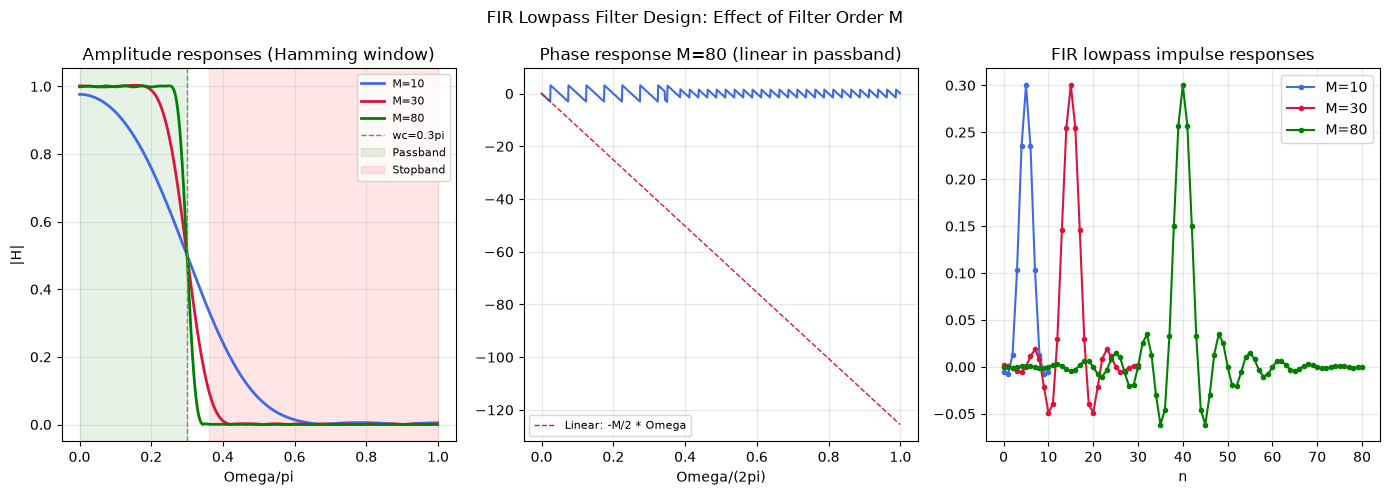

In [2]:
# Squared amplitude response example: b=[1,2]
b_s=np.array([1,2])
omega=np.linspace(0,np.pi,500)
H_s=1+2*np.exp(-1j*omega)
H2=np.abs(H_s)**2
H2_formula=5+4*np.cos(omega)
print('|H(e^jw)|^2 = (1+2e^-jw)(1+2e^jw) = 5+4cos(w):')
print(f'  Max error vs formula: {np.max(np.abs(H2-H2_formula)):.2e}')

# Design FIR lowpass filter (without scipy.signal.firpm, use windowed sinc)
def fir_lowpass_window(M, omega_c, window='hamming'):
    n=np.arange(M+1)-(M/2)
    h=np.sinc(omega_c/np.pi*n)*omega_c/np.pi
    if window=='hamming':
        w=0.54-0.46*np.cos(2*np.pi*np.arange(M+1)/M)
    elif window=='rect':
        w=np.ones(M+1)
    return h*w

fig,axes=plt.subplots(1,3,figsize=(14,5))

omega_full=np.linspace(0,np.pi,1000)
omega_c=0.3*np.pi

for M,col,lbl in [(10,'royalblue','M=10'),(30,'crimson','M=30'),(80,'green','M=80')]:
    b_lp=fir_lowpass_window(M,omega_c)
    H_lp=np.fft.fft(b_lp,2000)
    w_lp=np.arange(2000)/2000*2*np.pi
    axes[0].plot(w_lp[:1000]/np.pi,np.abs(H_lp[:1000]),color=col,lw=2,label=lbl)

axes[0].axvline(omega_c/np.pi,color='gray',ls='--',lw=1,label=f'wc={omega_c/np.pi:.1f}pi')
axes[0].axvspan(0,omega_c/np.pi,alpha=0.1,color='green',label='Passband')
axes[0].axvspan(omega_c/np.pi*1.2,1,alpha=0.1,color='red',label='Stopband')
axes[0].set_title('Amplitude responses (Hamming window)'); axes[0].legend(fontsize=8)
axes[0].set_xlabel('Omega/pi'); axes[0].set_ylabel('|H|'); axes[0].grid(True,alpha=0.3)

# Phase response (linear for symmetric filter)
b_lp80=fir_lowpass_window(80,omega_c)
H_lp80=np.fft.fft(b_lp80,2000)
phase=np.angle(H_lp80[:1000])
axes[1].plot(np.arange(1000)/1000,phase,'royalblue',lw=1.5)
# Expected linear: -M/2 * omega
omega_ax=np.arange(1000)/1000*np.pi
axes[1].plot(np.arange(1000)/1000,-80/2*omega_ax,'crimson',lw=1,ls='--',label='Linear: -M/2 * Omega')
axes[1].set_title('Phase response M=80 (linear in passband)')
axes[1].set_xlabel('Omega/(2pi)'); axes[1].legend(fontsize=8); axes[1].grid(True,alpha=0.3)

# Impulse responses
for M,col,lbl in [(10,'royalblue','M=10'),(30,'crimson','M=30'),(80,'green','M=80')]:
    b_lp=fir_lowpass_window(M,omega_c)
    axes[2].plot(range(len(b_lp)),b_lp,color=col,marker='.',label=lbl)
axes[2].set_title('FIR lowpass impulse responses'); axes[2].legend(); axes[2].grid(True,alpha=0.3)
axes[2].set_xlabel('n')

plt.suptitle('FIR Lowpass Filter Design: Effect of Filter Order M', fontsize=12)
plt.tight_layout(); plt.show()

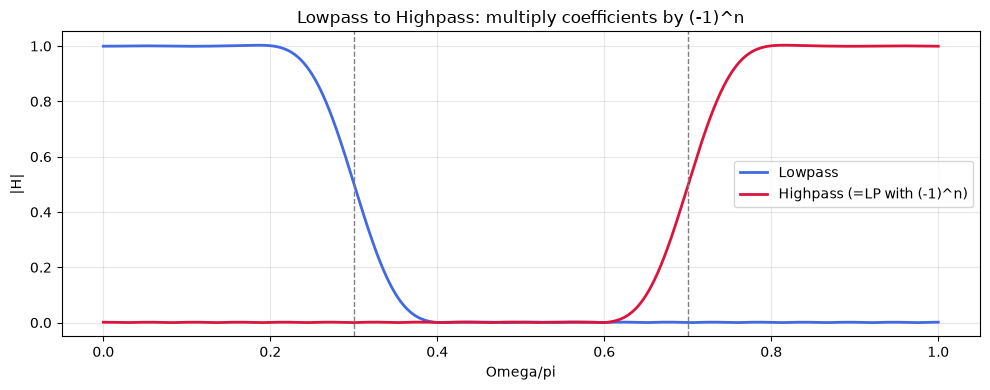

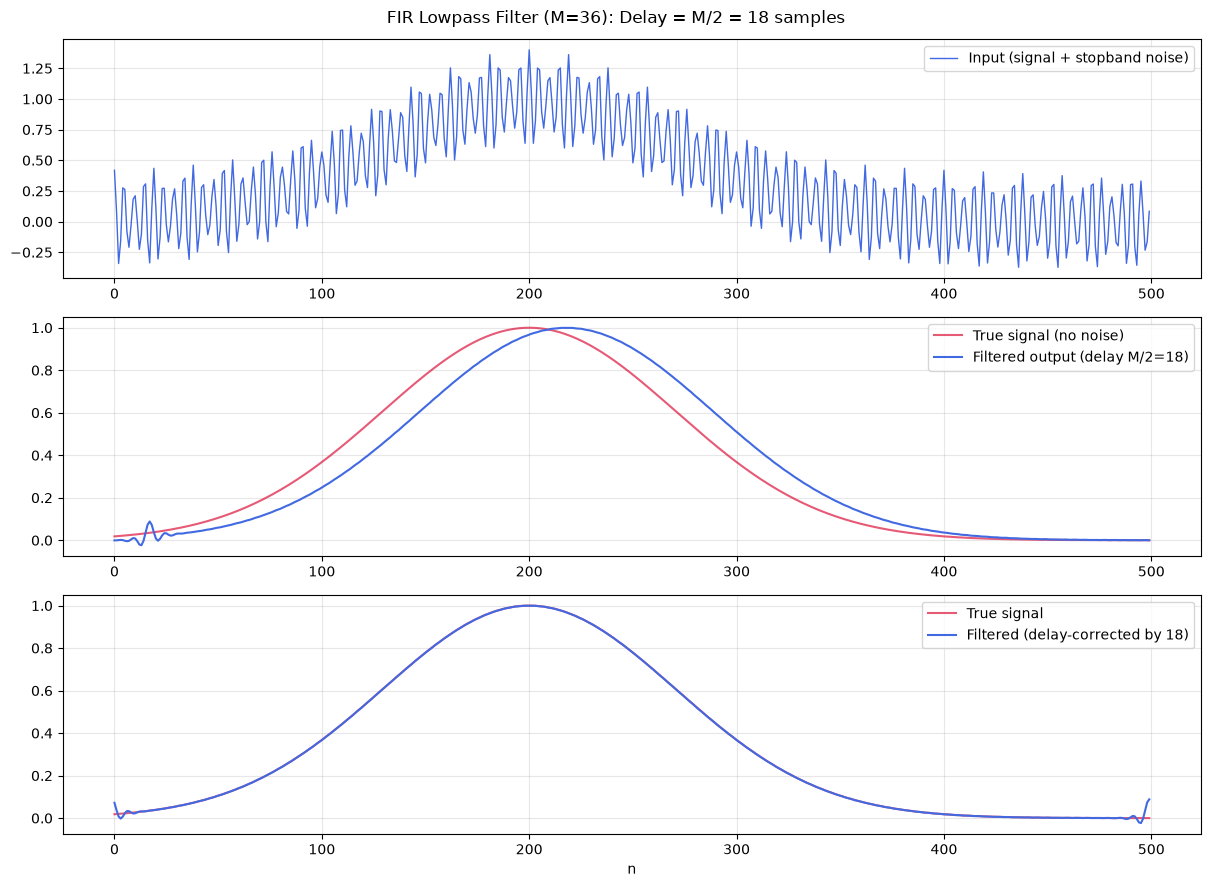

In [3]:
# Lowpass-to-Highpass conversion: multiply by (-1)^n
M=36; omega_c=0.3*np.pi
b_lp_final=fir_lowpass_window(M,omega_c)

# Highpass: multiply by (-1)^n
b_hp=b_lp_final * (-1)**np.arange(M+1)

# Compare responses
N_fft=2048
omega=np.linspace(0,np.pi,N_fft//2)
H_lp=np.abs(np.fft.fft(b_lp_final,N_fft)[:N_fft//2])
H_hp=np.abs(np.fft.fft(b_hp,N_fft)[:N_fft//2])

fig,ax=plt.subplots(figsize=(10,4))
ax.plot(omega/np.pi,H_lp,'royalblue',lw=2,label='Lowpass')
ax.plot(omega/np.pi,H_hp,'crimson',lw=2,label='Highpass (=LP with (-1)^n)')
ax.axvline(omega_c/np.pi,color='gray',ls='--',lw=1)
ax.axvline(1-omega_c/np.pi,color='gray',ls='--',lw=1)
ax.set_xlabel('Omega/pi'); ax.set_ylabel('|H|')
ax.set_title('Lowpass to Highpass: multiply coefficients by (-1)^n')
ax.legend(); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()

# Demonstrate filter in action
n_sig=np.arange(500)
# Gaussian envelope (passband signal)
s_env=np.exp(-((n_sig-200)**2)/100**2)
# Add noise in stopband
z_noise=0.3*np.cos(0.42*np.pi*n_sig)+0.1*np.cos(0.53*np.pi*n_sig)
x_total=s_env+z_noise

# Apply lowpass filter
y_lp=np.convolve(b_lp_final,x_total)[:len(n_sig)]

fig,axes=plt.subplots(3,1,figsize=(12,9))
axes[0].plot(n_sig,x_total,'royalblue',lw=1,label='Input (signal + stopband noise)')
axes[0].legend(); axes[0].grid(True,alpha=0.3)
axes[1].plot(n_sig,s_env,'crimson',lw=1.5,alpha=0.7,label='True signal (no noise)')
axes[1].plot(n_sig,y_lp,'royalblue',lw=1.5,label=f'Filtered output (delay M/2={M//2})')
axes[1].legend(); axes[1].grid(True,alpha=0.3)
# Note delay
delay=M//2
axes[2].plot(n_sig,s_env,'crimson',lw=1.5,alpha=0.7,label='True signal')
axes[2].plot(n_sig,np.roll(y_lp,-delay),'royalblue',lw=1.5,label=f'Filtered (delay-corrected by {delay})')
axes[2].legend(); axes[2].grid(True,alpha=0.3)
axes[2].set_xlabel('n')
plt.suptitle(f'FIR Lowpass Filter (M={M}): Delay = M/2 = {M//2} samples', fontsize=12)
plt.tight_layout(); plt.show()

---
## Summary

| Concept | Formula |
|---|---|
| z-transform | $X(z)=\sum_n x[n]z^{-n}$ |
| Convolution → z | $Y(z)=H(z)X(z)$ |
| Squared amplitude | $|H(e^{j\Omega})|^2=H(e^{j\Omega})H(e^{-j\Omega})$ |
| LP→HP conversion | $\tilde{b}_n=(-1)^n b_n$ |
| Symmetric FIR delay | $M/2$ samples |
| Phase response (symm) | $\angle H(e^{j\Omega})=-M\Omega/2$ (passband) |

### Mistakes to Avoid
1. An ideal lowpass (sharp cutoff) **cannot** be exactly realized by an FIR filter.
2. The delay is $M/2$ samples — for odd $M$ this is a non-integer. Symmetric FIR filters always introduce this delay.
3. Larger $M$ = better frequency selectivity BUT longer delay AND more computation — always a tradeoff.
4. LP→HP: multiply by $(-1)^n$ in time = shift spectrum by $\pi$ in frequency.
